In [1]:
import torch
import os
import random
import utils
import data_utils
import json
import clip
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from collections import Counter
import cbm_MM
import math
from PIL import Image
import pandas as pd
import csv
import matplotlib.pyplot as plt
import pickle
from visualization import plots

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/transformers/src/transformers/utils/hub.py:119: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


## Load weight and model

In [ ]:
load_dir = "saved_models/MMCBM_imagenet_CLIP_ViT-L-14"# path of model weights

with open(os.path.join(load_dir, "args.txt"), "r") as f:
    args = json.load(f)
dataset = args['dataset']

device = args['device']
batch_size = 512
if args["nec"] != 0:
    top_n = args['nec']
else:
    top_n = 5
_, target_preprocess = data_utils.get_target_model(args["backbone"], device)
weights = torch.load(os.path.join(load_dir ,"proj_model_weights.pt"), map_location=device)
model = cbm_MM.CBM_model(args["backbone"], weights, device=device, proj_type = args['proj_type'])
model.eval()

CBM_model(
  (proj): ProjModel_2CBL(
    (fc1): MLP(
      (projection): Linear(in_features=768, out_features=4751, bias=True)
      (gelu): GELU(approximate='none')
      (fc): Linear(in_features=4751, out_features=4751, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (fc2): MLP(
      (projection): Linear(in_features=768, out_features=4751, bias=True)
      (gelu): GELU(approximate='none')
      (fc): Linear(in_features=4751, out_features=4751, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
)

In [3]:
val_d_probe = dataset+"_val"
cls_file = data_utils.LABEL_FILES[dataset]

val_data_t = data_utils.get_data(val_d_probe, preprocess=target_preprocess)
val_pil_data = data_utils.get_data(val_d_probe)

val_targets = data_utils.get_targets_only(val_d_probe)

In [4]:
with open(cls_file, "r") as f:
    classes = f.read().split("\n")

with open(os.path.join(load_dir, "concepts.txt"), "r") as f:
    concepts = f.read().split("\n")

In [5]:
classes_idx_sentence = [[] for i in range(len(classes))]
for i, target in enumerate(val_targets):
    classes_idx_sentence[target].append(i)

In [6]:
encoded_images = []

for imgs, _ in tqdm(DataLoader(val_data_t, batch_size=batch_size, num_workers=6, pin_memory=True)):
    with torch.no_grad():
        img = model.encode_image(imgs.to(device))
    encoded_images.append(img)

encoded_images = torch.cat(encoded_images, dim=0)

  8%|▊         | 8/98 [00:23<02:47,  1.86s/it]

100%|██████████| 98/98 [02:34<00:00,  1.58s/it]


## Diverse sentence template to test robustness

In [7]:
templates = [
    "A photo of a {}.",
    "An image of a {}.",
    "A close-up of a {}.",
    "A picture of a {}.",
    "A cropped photo of a {}.",
    "A photo of a big {}",
    "A photo of a small {}",
    "This is a {}.",
    "The image depicts a {}.",
    "The image appears to be a picture of a {}.",
    "This is a blurry image of a {}.",
    "It is a {}.",
    "It would be a picture of a {}.",
    "The image shows {}."
]

In [8]:
encoded_texts = torch.zeros(len(classes), len(concepts))

for template in templates:
    class_texts = []
    for cls in classes:
        class_texts.append(template.format(cls))

    with torch.no_grad():
        class_texts_tokenized = clip.tokenize(class_texts).to(device)
        encoded_texts_cur = model.encode_text(class_texts_tokenized)
        encoded_texts = encoded_texts + encoded_texts_cur.cpu()
        del encoded_texts_cur, class_texts_tokenized
        torch.cuda.empty_cache()

encoded_texts = encoded_texts.to(device)

## Evaluate task performance

In [9]:
with torch.no_grad():
    temp = model.temp()
    encoded_images = torch.clamp(encoded_images, min=0)
    I_e = F.normalize(encoded_images, p=2, dim=-1)
    encoded_texts = torch.clamp(encoded_texts, min=0)
    T_e = F.normalize(encoded_texts, p=2, dim=-1)

batch_size = 256
if args['dataset'] == 'cc12m':
    logits = (I_e @ T_e.T) * torch.exp(temp)
else:
    logits = []
    valid_indices = []

    for i in tqdm(range(math.ceil(len(val_targets)/batch_size))):
        prelogit = I_e[batch_size*i:batch_size*(i+1)].unsqueeze(1) * T_e
        top_values, top_indices = torch.topk(prelogit, top_n)
        valid_indices.append(top_indices)
        logits.append((torch.sum(top_values, dim=2) * torch.exp(temp)).cpu())
    logits = torch.cat(logits, dim=0).to(args['device'])

_, pred = torch.softmax(logits, dim=1).topk(1, 1, True, True)

cbm_MM.accuracy(torch.softmax(logits, dim=1).to('cuda'), torch.tensor(val_targets).to('cuda'), (1,5))

100%|██████████| 196/196 [00:11<00:00, 17.23it/s]


[81.8740005493164, 95.0060043334961]

## Sankey Plot

In [10]:
k = 10
topk_values, topk_indices = torch.topk(T_e, k, dim=1)

to_show = random.choices([i for i in range(len(classes))], k=1)

for i in to_show:
    print("Output class:{} - {}".format(i, classes[i]))
    print("Incoming weights:")
    for j in topk_indices[i]:
        print("{} [{:.4f}] {}".format(concepts[j], T_e[i,j].item(), classes[i]))

Output class:545 - electric fan
Incoming weights:
electrical device [0.6998] electric fan
appliance [0.4866] electric fan
fan [0.2854] electric fan
attached to a window frame [0.1504] electric fan
attached to a long shaft [0.1432] electric fan
large spiny plant [0.1173] electric fan
black fur with white markings [0.1038] electric fan
headphones [0.1030] electric fan
storage device [0.0831] electric fan
rubber brake pads [0.0722] electric fan


You can build a Sankey diagram of weights by copying the incoming weights printed below into https://sankeymatic.com/build/

## Calculate accuracy for each class

In [11]:
val_targets = torch.tensor(val_targets).to(device)
pred = pred.squeeze()
acc_by_class = {}
for i in range(len(classes)):
    target_class_mask = (val_targets == i)

    correct_predictions = (pred[target_class_mask] == val_targets[target_class_mask]).sum().item()
    total_target_class = target_class_mask.sum().item()

    acc = (correct_predictions / total_target_class) * 100
    acc_by_class[classes[i]] = acc

## Interpretable result for both groud-truth label and prediction

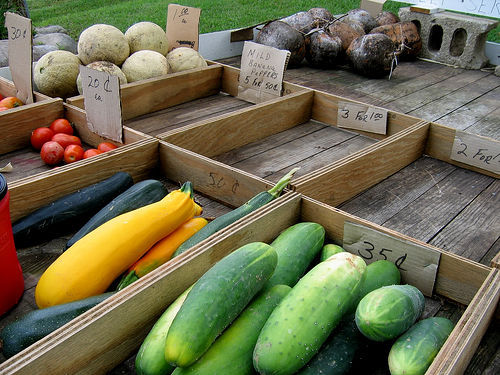

image id:  46987
label:  939 zucchini
The 5 most relevant concepts: ['vegetable', 'sea vegetable', 'food', 'plants', '"police" or "sheriff" markings']
tensor([0.1828, 0.0922, 0.0217, 0.0066, 0.0000], device='cuda:0')
prediction:  943 cucumber
The 5 most relevant concepts: ['vegetable', 'sea vegetable', 'cilantro', 'plants', 'food']
tensor([0.1625, 0.0787, 0.0769, 0.0391, 0.0372], device='cuda:0')
visual concepts activations
Top-10 concepts ['blunt end', 'cucumber plant', 'plant', 'cilantro', 'sea vegetable', 'vegetable', 'plants', 'food', 'watery texture', 'store']
Activations tensor([0.5742, 0.4295, 0.3755, 0.3338, 0.2769, 0.2403, 0.1863, 0.1275, 0.1274,
        0.1001], device='cuda:0')
label concepts activations
Top-10 concepts ['vegetable', 'sea vegetable', 'food', 'gourd', 'thick bumpy skin', 'dog food', 'darkness', 'organism', 'breed of dog', 'other crocodiles']
Activations tensor([0.7607, 0.3331, 0.1703, 0.1603, 0.1541, 0.1276, 0.1267, 0.1192, 0.1161,
        0.1152], device='cu

In [12]:
id = random.randrange(0, 50000)
top_values, top_indices = torch.topk(I_e[id] * T_e, top_n)

image, label = val_pil_data[id]

prediction = pred[id]

concepts_result = [[concepts[idx] for idx in row] for row in top_indices]

display(image)

print("image id: ", id)

print("label: ",label , classes[label])
print("The 5 most relevant concepts:", concepts_result[label])
print(top_values[label])

print("prediction: ", int(prediction), classes[prediction])
print("The 5 most relevant concepts:", concepts_result[prediction])
print(top_values[prediction])

top_values, top_indices = torch.topk(I_e[id],10)
concepts_result = [concepts[idx] for idx in top_indices]
print("visual concepts activations")
print("Top-10 concepts", concepts_result)
print("Activations", top_values)

top_values, top_indices = torch.topk(T_e[label],10)
concepts_result = [concepts[idx] for idx in top_indices]
print("label concepts activations")
print("Top-10 concepts", concepts_result)
print("Activations", top_values)

top_values, top_indices = torch.topk(T_e[prediction],10)
concepts_result = [concepts[idx] for idx in top_indices]
print("prediction concepts activations")
print("Top-10 concepts", concepts_result)
print("Activations", top_values)
